In [39]:
import polars as pl

wanted_pitchers = [693821, 519242, 656550, 680885, 700363, 625643, 666214,
                   694462, 607200]
baseball_radius = (2.9 / 12)  # baseball radius in feet
overrides = {'break_length': pl.Float64}
df = pl.scan_parquet('data/processed/livefeeds/2025/*.parquet',
                     missing_columns='insert')
df = df.filter(pl.col('pitcher_id').is_in(wanted_pitchers))
df = df.with_columns(pl.when(pl.col('half_inning') == 'top')
                     .then(pl.lit('away'))
                     .otherwise(pl.lit('home')).alias('home_away'))
df = df.with_columns(
    pl.when(pl.col('pz').is_between(pl.col('pitch_strike_zone_bottom'),
                                    pl.col('pitch_strike_zone_top')) & pl.col(
        'px').is_between(-1 * (.708 + baseball_radius),
                         (.708 + baseball_radius)))
    .then(pl.lit(True))
    .otherwise(pl.lit(False)).alias('in_strike_zone'))
braves_pitches = df.collect()

"""
away_pitches = df.filter(pl.col('half_inning') == 'bottom')
home_pitches = df.filter(pl.col('half_inning') == 'top')
home_pitches = home_pitches.with_columns(
    pl.col('pitcher_id').cum_count().over('pitcher_id').alias('pitch_index'))
home_pitches = home_pitches.with_columns(
    pl.col("pitch_index").shift(1).over('pitcher_id').alias(
        'previous_pitch_index'))
away_pitches = away_pitches.with_columns(
    pl.col('pitcher_id').cum_count().over('pitcher_id').alias('pitch_index'))
away_pitches = away_pitches.with_columns(
    pl.col("pitch_index").shift(1).over('pitcher_id').alias(
        'previous_pitch_index'))

home_pitches = home_pitches.join(home_pitches,
                                 left_on=['pitcher_id', 'pitch_index'],
                                 right_on=['pitcher_id', 'pitch_index'],
                                 how='left', suffix='_prev')

away_pitches = away_pitches.join(
    away_pitches, left_on=['pitcher_id', 'pitch_index'],
    right_on=['pitcher_id', 'pitch_index'], how='left', suffix='_prev')
"""


'\naway_pitches = df.filter(pl.col(\'half_inning\') == \'bottom\')\nhome_pitches = df.filter(pl.col(\'half_inning\') == \'top\')\nhome_pitches = home_pitches.with_columns(\n    pl.col(\'pitcher_id\').cum_count().over(\'pitcher_id\').alias(\'pitch_index\'))\nhome_pitches = home_pitches.with_columns(\n    pl.col("pitch_index").shift(1).over(\'pitcher_id\').alias(\n        \'previous_pitch_index\'))\naway_pitches = away_pitches.with_columns(\n    pl.col(\'pitcher_id\').cum_count().over(\'pitcher_id\').alias(\'pitch_index\'))\naway_pitches = away_pitches.with_columns(\n    pl.col("pitch_index").shift(1).over(\'pitcher_id\').alias(\n        \'previous_pitch_index\'))\n\nhome_pitches = home_pitches.join(home_pitches,\n                                 left_on=[\'pitcher_id\', \'pitch_index\'],\n                                 right_on=[\'pitcher_id\', \'pitch_index\'],\n                                 how=\'left\', suffix=\'_prev\')\n\naway_pitches = away_pitches.join(\n    away_pitches, le

In [40]:
braves_pitches.select('x', 'y', 'px', 'pz', 'pitch_strike_zone_top',
                      'pitch_strike_zone_bottom',
                      'pitch_start_speed', 'pitch_type', 'pitcher_name',
                      'pitcher_id')

x,y,px,pz,pitch_strike_zone_top,pitch_strike_zone_bottom,pitch_start_speed,pitch_type,pitcher_name,pitcher_id
f64,f64,f64,f64,f64,f64,f64,str,str,i64
152.76,144.4,-0.938035,3.495448,3.180001,1.452478,91.5,"""Four-Seam Fastball""","""Joey Wentz""",666214
101.51,148.46,0.406252,3.345145,3.18,1.45,92.9,"""Four-Seam Fastball""","""Joey Wentz""",666214
135.98,145.15,-0.49788,3.467681,3.18,1.45,92.6,"""Four-Seam Fastball""","""Joey Wentz""",666214
140.26,156.31,-0.610257,3.054552,3.18,1.45,94.1,"""Four-Seam Fastball""","""Joey Wentz""",666214
110.69,162.74,0.165502,2.816285,3.21,1.4,92.9,"""Four-Seam Fastball""","""Joey Wentz""",666214
…,…,…,…,…,…,…,…,…,…
86.64,166.61,0.429924,1.913341,3.461,1.747,86.1,"""Slider""","""Bryce Elder""",693821
87.08,192.98,-2.433906,1.926728,3.461,1.747,94.0,"""Sinker""","""Bryce Elder""",693821
112.49,199.1,-1.491141,1.954573,3.461,1.747,93.0,"""Sinker""","""Bryce Elder""",693821


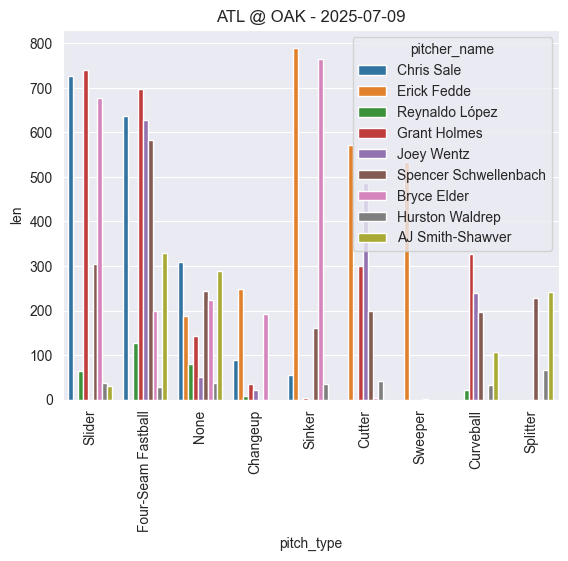

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

pitch_counts = braves_pitches.group_by('pitcher_id', 'pitcher_name',
                                       'pitch_type').len().sort(
    'pitcher_id', 'len', descending=[False, True])
starter_df = pitch_counts
sns.barplot(starter_df, x='pitch_type', y='len', hue='pitcher_name')
plt.xticks(rotation=90)
plt.title('ATL @ OAK - 2025-07-09')
plt.show()

In [3]:
away_pitches.game_id

AttributeError: 'DataFrame' object has no attribute 'game_id'

<Axes: xlabel='pitch_start_speed', ylabel='Count'>

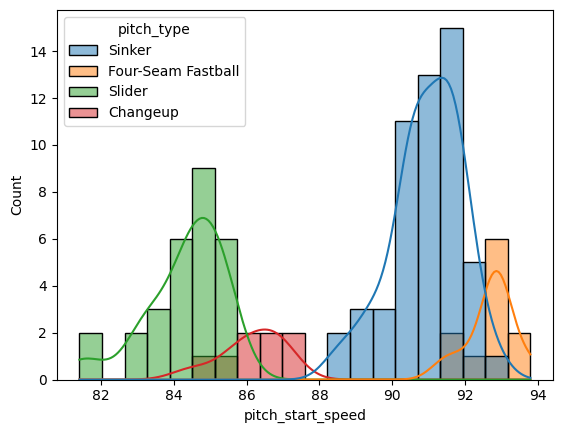

In [24]:
sns.histplot(
    data=away_pitches.filter((pl.col('pitcher_name') == 'Bryce Elder')),
    x='pitch_start_speed',
    hue='pitch_type', kde=True, bins=20)


In [ ]:
#TODO compare pitch breakdown between season starters [Chris Sale, Spencer Schwellenbach, Grant Holmes, AJ SMith-Schaver and end of season starters [Bryce Elder, joey wentz, eric fedde, hurston waldrep]

wanted_pitchers = [693821, 519242, 656550, 680885, 700363, 625643, 666214,
                   694462,
                   607200]
#also compare pitch breakdown by ball, strike